# Pareto Frontiers & Trade-offs

Goal: show trade-offs between metrics and identify Pareto-optimal algorithms.

Expected takeaway: which methods dominate across multiple objectives.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / "combined_wide.csv")
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")
combined["seed"] = combined["seed"].astype(str)

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
final = agg[agg["Step"] == final_step].copy()


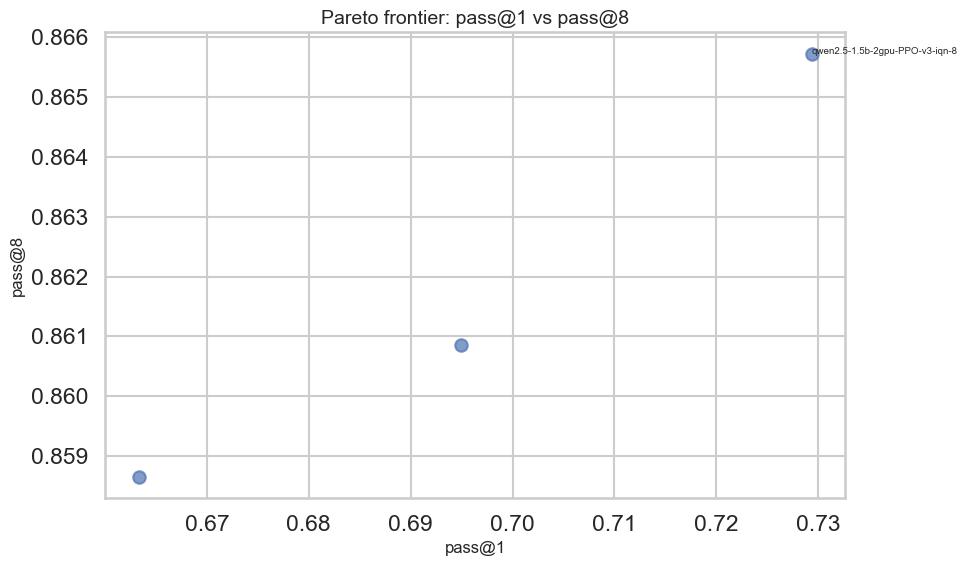

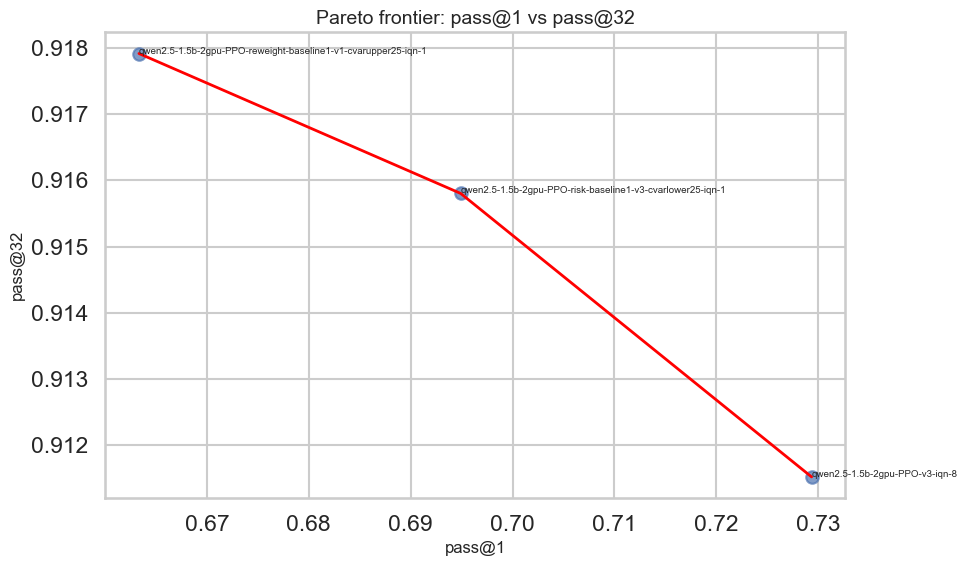

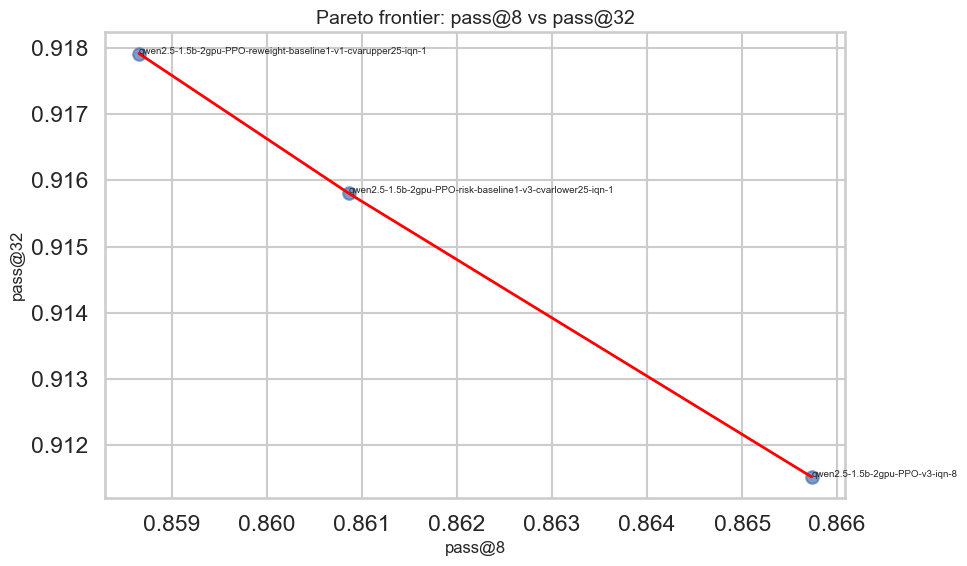

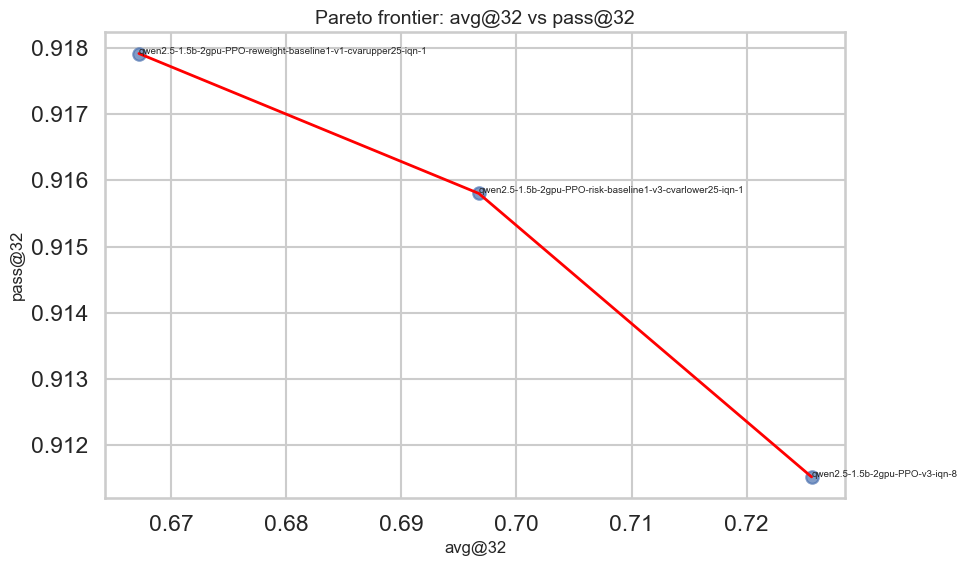

In [3]:
# Helper: compute Pareto front

def pareto_front(df, x, y):
    # Maximize both x and y
    df = df.sort_values([x, y], ascending=False)
    front = []
    best_y = -np.inf
    for _, row in df.iterrows():
        if row[y] >= best_y:
            front.append(row)
            best_y = row[y]
    return pd.DataFrame(front)

pairs = [("pass@1", "pass@8"), ("pass@1", "pass@32"), ("pass@8", "pass@32"), ("avg@32", "pass@32")]

for x, y in pairs:
    new_fig(f"Pareto frontier: {x} vs {y}")
    plt.scatter(final[x], final[y], alpha=0.7)
    front = pareto_front(final, x, y)
    plt.plot(front[x], front[y], color="red", linewidth=2)
    for _, r in front.iterrows():
        plt.text(r[x], r[y], r["algorithm"], fontsize=7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()


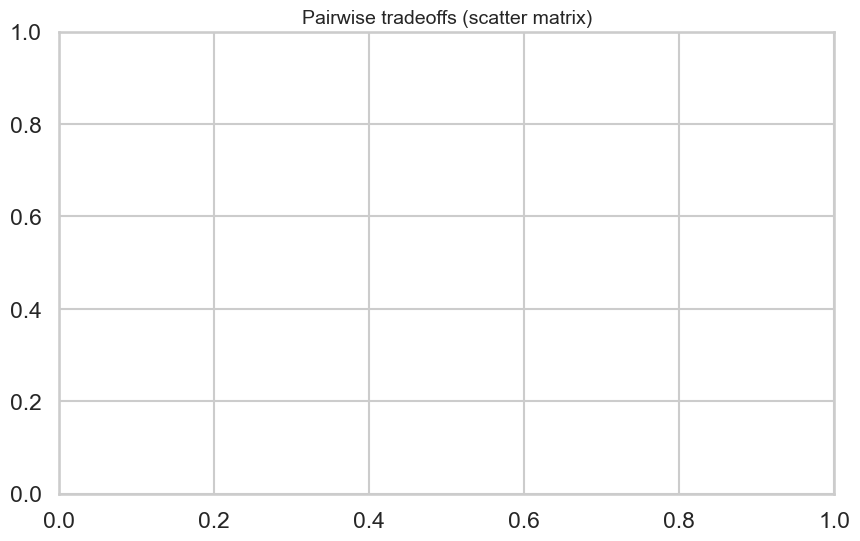

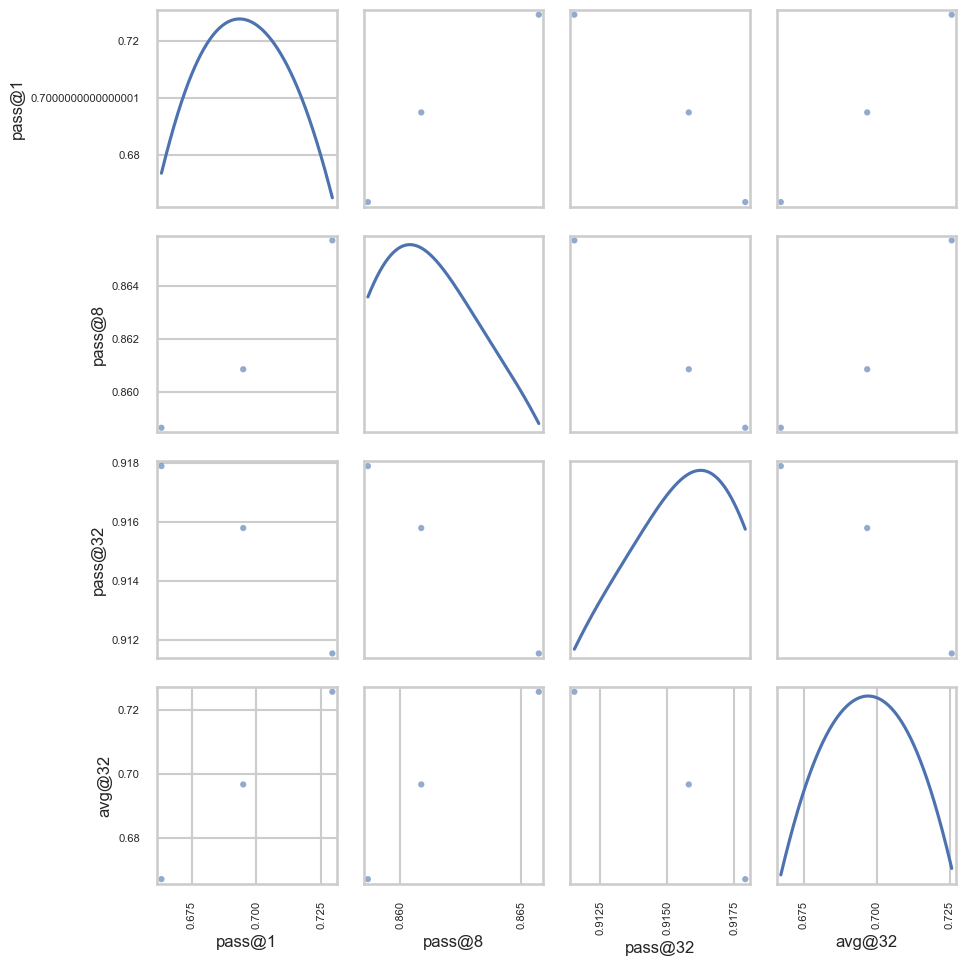

Generated 5 figures


In [4]:
# Plot 2: 3D-ish tradeoff via pairwise matrix
metrics = ["pass@1", "pass@8", "pass@32", "avg@32"]
new_fig("Pairwise tradeoffs (scatter matrix)")
from pandas.plotting import scatter_matrix
scatter_matrix(final[metrics], figsize=(10, 10), diagonal="kde", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Generated {PLOT_COUNTER} figures")
